<div style="width:100%; background-color:#181818; color:#f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media.giphy.com/media/L8K62iTDkzGX6/giphy.gif" alt="Beam Oscillation" width="600" style="border-radius:10px;">

  <h3 style="color:#ffffff; margin-top:15px;"><b>CÁLCULO MANUAL DE DESPLAZAMIENTO VERTICAL, UNIDAD #3</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:#3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Computational Methods in Structural Engineering</p>
  <p><b>Year:</b> NOV - 2025</p>

</div>


<!-- <div style="margin-left:100px; margin-right:100px; margin-top:40px; text-indent:40px" align="justify"> -->
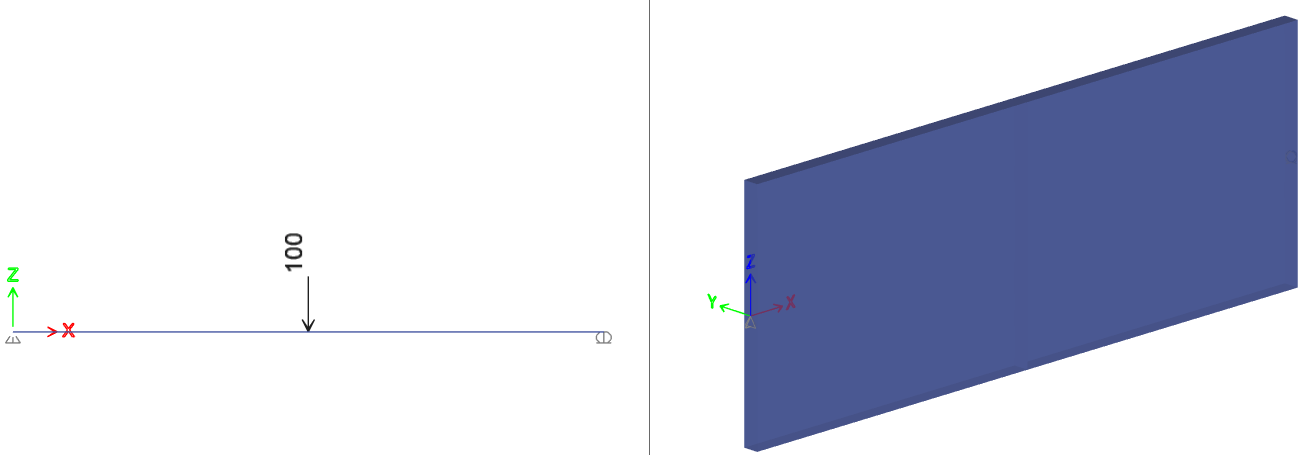
<!-- <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e8/Taipei_101_from_Xiangshan_20240729.jpg/800px-Taipei_101_from_Xiangshan_20240729.jpg" width="300" style="box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.6); margin-right: 20px;"/> -->
<!-- <img src="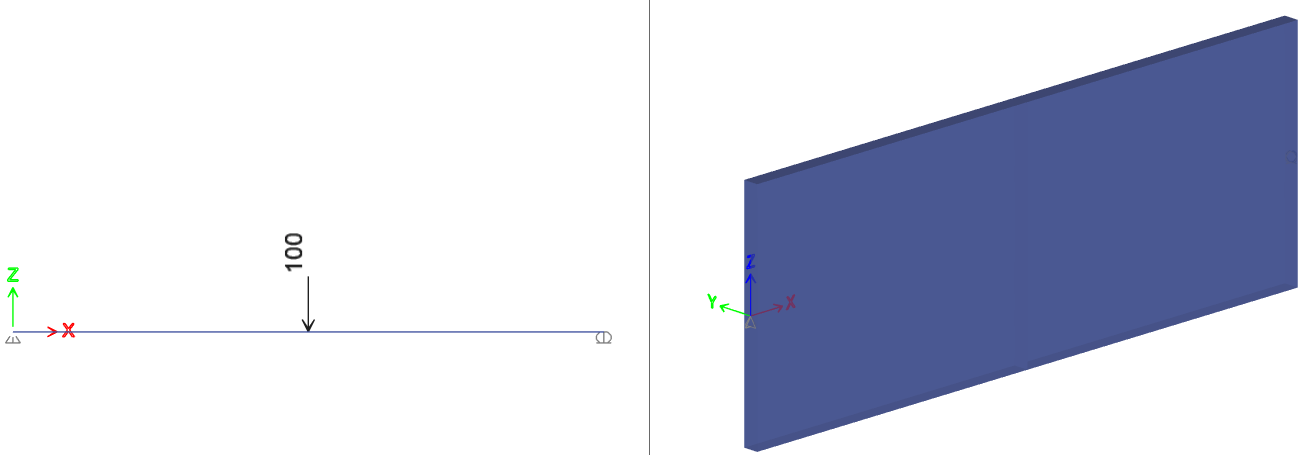" width="300" style="box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.6); margin-right: 20px;"/> -->
<!-- </div> -->

### **Librerias**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import os
import glob
from pathlib import Path
# %matplotlib inline
# %matplotlib widget

In [2]:
from repo_computational_methods import *

### **Datos de Entrada**

In [3]:
p = 100                                                                       # applied load (force) value
h = 3.00                                                                      # beam height
b = 0.20                                                                      # beam width
A = h*b                                                                       # cross-sectional area (A = h * b)
I = b*h**(3) / 12                                                             # second moment of area for rectangle (I = b*h^3/12)
E = 2000000                                                                   # Young's modulus
u = 0.20                                                                      # Poisson's ratio
f = 6/5                                                                       # correction factor (dimensionless)
L = 8                                                                         # span length
Rg = np.sqrt(I / A)                                                           # radius of gyration (sqrt(I/A))
numdiv = 10                                                                   # number of divisions ("Frame")
dpart = 0.20                                                                  # partition size
poreje = 0.30                                                                 # percentege of division 

### **Solución de Desplazamiento**

$$
\delta = \frac{p\,L^3}{48\,E\,I}\left(1 + 24\,(1+\nu)\,f\left(\frac{R_g}{L}\right)^2\right)
$$

Where:
- $\delta$ represents the **deflection** at midspan,
- $p$ is the **Point load** $[T]$,
- $L$ is the **span length** $[m]$,
- $E$ is the **modulus of elasticity** $[T/m^2]$,
- $I$ is the **second moment of area** $[m^4]$,
- $\nu$ is the **Poisson’s ratio**,
- $f$ is a **correction factor** for shear and rotary effects,
- $R_g$ is the **radius of gyration** $[m]$.


In [4]:
d = p * L**3 / (48 * E * I) * (1 + 24 * (1 + u) * f *(Rg / L)**2) * -1        # deflection formula including shear and rotary effects
d = np.array([d])                                                             # convert deflection to a numpy array
d_df = pd.DataFrame(d, columns=['Deflection [m]'])                            # create a DataFrame for the deflection
d_df.head(len(d_df))                                                          # display all rows of the deflection DataFrame

,Deflection [m]
0,-0.001665


##### **Desplazamientos y Flexión a lo largo del elemento (0 - L/2)**

$$
\delta(x) = \frac{P}{E\,I} 
\left( \frac{x^3}{12} - \frac{L^2}{16}\,x \right)
\left[ 1 + 24\,(1+\nu)\,f\left( \frac{R_g}{L} \right)^2 \right]
$$

Where:
- $\delta(x)$ is the **deflection** at a distance $x$ along the beam,
- $P$ is the **applied load** $[T]$,
- $E$ is the **modulus of elasticity** $[T/m^2]$,
- $I$ is the **moment of inertia** $[m^4]$,
- $L$ is the **total span length** $[m]$,
- $\nu$ is the **Poisson’s ratio**,
- $f$ is a **correction factor** accounting for shear and rotary inertia,
- $R_g$ is the **radius of gyration** of the section $[m]$.

$$
M(x) = 
\begin{cases}
\dfrac{P}{2}\,x, & 0 \le x \le \dfrac{L}{2}, \\[8pt]
\dfrac{P}{2}\,(L - x), & \dfrac{L}{2} \le x \le L.
\end{cases}
$$

Where:
- $M(x)$ is the **bending moment** at a distance $x$ along the beam,
- $P$ is the **applied load** $[T]$,
- $L$ is the **total span length** $[m]$,
- $x$ is the **position** measured from the left support $[m]$.



In [5]:
elem = np.array([[0, 0], [L, 0]])                                               # element coordinates (start at x=0, end at x=L)

d_x1 = []                                                                       # list to store deflections 0 - L/2
d_x2 = []                                                                       # list to store deflections L/2 - L (will be filled as mirrored later)
elemn_div = []                                                                  # list for positions 0 - L/2
elemn_div2 = []                                                                 # list for positions L/2 - L

Mx = []                                                                         # list to store moment values 0 - L/2
Mx2 = []                                                                        # list to store moment values L/2 - L (will be filled as mirrored later)

dv = (1 + 24 * (1 + u) * f *(Rg / L)**2)                                        # correction factor for shear and rotary effects (dv)

for x1 in np.arange(0, L/2 + dpart, dpart):                                     # sampling from 0 to L/2 with step dpart
    dx1_1 = p / (E * I) * (x1**(3) / (12) - L**(2) * x1 / (16))                 # analytical expression of δ(x) without dv factor
    d_x1.append(dx1_1 * dv)                                                     # store corrected δ(x) for 0 - L/2
    elemn_div.append(x1)                                                        # store position x1 for 0 - L/2
    elemn_div2.append(x1 + L/2)                                                 # store corresponding position in L/2 - L
    
    Mx.append(p * x1 / 2 * - 1)                                                 # calculate and store moment at position x1
    
elemn_div = np.array(elemn_div)                                                 # convert positions 0 - L/2 to ndarray
elemn_div2 = np.array(elemn_div2)                                               # convert positions L/2 - L to ndarray
d_x1 = np.array(d_x1)                                                           # convert deflections 0 - L/2 to ndarray
d_x2 = np.flip(d_x1)                                                            # generate deflections L/2 - L by flipping d_x1

Mx = np.array(Mx)                                                               # convert moment 0 - L/2 to ndarray
Mx2 = np.flip(Mx)                                                               # generate moment L/2 - L by flipping Mx


elemn_div_df = pd.DataFrame(elemn_div, columns=['Position along beam 0 - L/2 [m]'])         # DataFrame positions 0 - L/2
elemn_div2_df = pd.DataFrame(elemn_div2, columns=['Position along beam L/2 - L [m]'])       # DataFrame positions L/2 - L
d_x1_df = pd.DataFrame(d_x1, columns=['Deflection 0 - L/2 [m]'])                            # DataFrame deflections 0 - L/2
d_x2_df = pd.DataFrame(d_x2, columns=['Deflection L/2 - L [m]'])                            # DataFrame deflections L/2 - L

Mx_df = pd.DataFrame(Mx, columns=['Moment 0 - L/2 [T-m]'])                                  # DataFrame moment 0 - L/2
Mx2_df = pd.DataFrame(Mx2, columns=['Moment L/2 - L [T-m]'])                                # DataFrame moment L/2 - L

dx = pd.concat([elemn_div_df, d_x1_df, elemn_div2_df, d_x2_df, Mx_df, Mx2_df], axis=1,
               ignore_index= False)                                                         # concatenate everything into a summary DataFrame
dx.head(len(dx))                                                                            # show all rows of the resulting DataFrame

,Position along beam 0 - L/2 [m],Deflection 0 - L/2 [m],Position along beam L/2 - L [m],Deflection L/2 - L [m],Moment 0 - L/2 [T-m],Moment L/2 - L [T-m]
0,0.0,0.000000,4.0,-0.001665,-0.0,-200.0
1,0.2,-0.000125,4.2,-0.001659,-10.0,-190.0
2,0.4,-0.000249,4.4,-0.001641,-20.0,-180.0
3,0.6,-0.000372,4.6,-0.001612,-30.0,-170.0
4,0.8,-0.000493,4.8,-0.001572,-40.0,-160.0
5,1.0,-0.000611,5.0,-0.001522,-50.0,-150.0
6,1.2,-0.000727,5.2,-0.001463,-60.0,-140.0
7,1.4,-0.000839,5.4,-0.001395,-70.0,-130.0
8,1.6,-0.000946,5.6,-0.001319,-80.0,-120.0
9,1.8,-0.001048,5.8,-0.001235,-90.0,-110.0


###### **Plots**

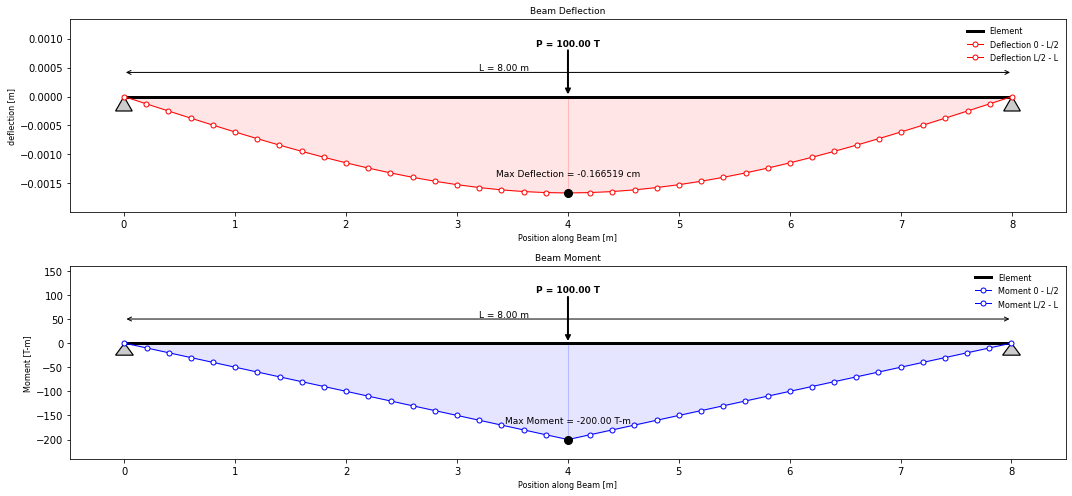

In [6]:
fig1, ax1 = plt.subplots(2, 1, figsize = (15,7))                                                                                                # create figure with 2 subplots (stacked) and set figure size
###################### Beam vs Deflections ######################

#### Supports ####
h_sup = 0.00025                                                                                                                                 # support height in meters (small for deflection plot)
b_sup = h_sup * 300                                                                                                                             # support base half-width scaled from support height
x0, xL = 0.0, L                                                                                                                                 # left and right x-coordinates of the beam
tri_left = patches.Polygon([[x0 - b_sup, -h_sup],                                                                                               # left support triangle polygon coordinates
                            [x0 + b_sup, -h_sup],
                            [x0, 0]], closed=True, facecolor= (0.8, 0.8, 0.8), edgecolor= (0, 0, 0), lw=1.2)                                    # appearance of left support
tri_rigth = patches.Polygon([[xL - b_sup, -h_sup],                                                                                              # right support triangle polygon coordinates
                            [xL + b_sup, -h_sup],
                            [xL, 0]], closed=True, facecolor= (0.8, 0.8, 0.8), edgecolor= (0, 0, 0), lw=1.2)                                    # appearance of right support

ax1[0].add_patch(tri_left)                                                                                                                      # add left support patch to top subplot
ax1[0].add_patch(tri_rigth)                                                                                                                     # add right support patch to top subplot

###################### Beam vs Deflections ######################
ax1[0].plot(elem[:,0], elem[:,1], color=(0, 0, 0), linestyle='-', linewidth=3.0, label="Element")                                               # plot beam baseline
ax1[0].plot(elemn_div, d_x1, color=(1, 0, 0), linestyle='-', linewidth=1.0,                                                                     # plot deflection from 0 to L/2
         marker = 'o',markersize = 5, markeredgecolor = (1,0,0),markerfacecolor = (1,1,1), label="Deflection 0 - L/2")
ax1[0].fill_between(elemn_div, d_x1, 0, color=(1, 0, 0), alpha=0.1)                                                                             # shade area under deflection curve (0-L/2)
ax1[0].plot(elemn_div2, d_x2, color=(1, 0, 0), linestyle='-', linewidth=1.0,                                                                    # plot deflection from L/2 to L (mirrored)
         marker = 'o',markersize = 5, markeredgecolor = (1,0,0),markerfacecolor = (1,1,1), label="Deflection L/2 - L")
ax1[0].fill_between(elemn_div2, d_x2, 0, color=(1, 0, 0), alpha=0.1)                                                                            # shade area under deflection curve (L/2-L)
ax1[0].plot(L/2, d[0], marker='o', markersize=8, markerfacecolor=(0, 0, 0), markeredgecolor=(0, 0, 0), markeredgewidth=1)                       # mark midspan deflection
ax1[0].text(L/2, d[0] - d[0]*0.2, f"Max Deflection = {d[0]*100:.6f} cm", rotation=0, va='center', ha='center', fontsize=9, color=(0, 0, 0))     # label max deflection in cm


ax1[0].annotate('', xy=(0, 0 - d * 0.25), xytext=(L, 0 - d * 0.25),                                                                             # double arrow showing beam span on deflection plot
               arrowprops=dict(arrowstyle='<->', linewidth=1))
ax1[0].text(L/2 - 0.10*L, 0 - d[0]*0.30, f"L = {L:.2f} m", rotation=0, va='center', ha='left', fontsize=9)                                      # annotate span length

ax1[0].annotate('', xy=(L/2, 0), xytext=(L/2, -d * 0.50),                                                                                       # arrow indicating applied point load at midspan
               arrowprops=dict(arrowstyle='->', linewidth=2))
ax1[0].text(L/2, -d * 0.55, f"P = {p:.2f} T", rotation=0, va='center', ha='center', fontsize=9, fontweight='bold')                              # label applied load


ax1[0].set_title(f'Beam Deflection', fontsize=9,color = [0, 0, 0])                                                                              # set title for deflection subplot
ax1[0].set_xlabel('Position along Beam [m]', fontsize=8)                                                                                        # x-axis label
ax1[0].set_ylabel('deflection [m]', fontsize=8)                                                                                                 # y-axis label
ax1[0].set_ylim(d[0]*1.2, -d[0]*0.8)                                                                                                            # set y-limits to frame deflection properly
ax1[0].legend(fontsize=8 , frameon=False)                                                                                                       # show legend without frame

###################### Beam vs Moment ######################
#### Supports ####
h_sup = 25                                                                                                                                      # support drawing height for moment subplot (visual scale)
b_sup = L * 0.01                                                                                                                                # support base width proportional to beam length for moment plot
x0, xL = 0.0, L                                                                                                                                 # left and right x-coordinates (redefined for clarity)
tri_left = patches.Polygon([[x0 - b_sup, -h_sup],                                                                                               # left support polygon for moment subplot
                            [x0 + b_sup, -h_sup],
                            [x0, 0]], closed=True, facecolor= (0.8, 0.8, 0.8), edgecolor= (0, 0, 0), lw=1.2)
tri_rigth = patches.Polygon([[xL - b_sup, -h_sup],                                                                                              # right support polygon for moment subplot
                            [xL + b_sup, -h_sup],
                            [xL, 0]], closed=True, facecolor= (0.8, 0.8, 0.8), edgecolor= (0, 0, 0), lw=1.2)

ax1[1].add_patch(tri_left)                                                                                                                      # add left support to bottom subplot
ax1[1].add_patch(tri_rigth)                                                                                                                     # add right support to bottom subplot

#### Deflections ####
ax1[1].plot(elem[:,0], elem[:,1], color=(0, 0, 0), linestyle='-', linewidth=3.0, label="Element")                                               # plot beam baseline on moment subplot
ax1[1].plot(elemn_div, Mx, color=(0, 0, 1), linestyle='-', linewidth=1.0,                                                                       # plot bending moment 0-L/2
         marker = 'o',markersize = 5, markeredgecolor = (0,0,1),markerfacecolor = (1,1,1), label="Moment 0 - L/2")
ax1[1].fill_between(elemn_div, Mx, 0, color=(0, 0, 1), alpha=0.1)                                                                               # shade area under moment curve (0-L/2)
ax1[1].plot(elemn_div2, Mx2, color=(0, 0, 1), linestyle='-', linewidth=1.0,                                                                     # plot bending moment L/2-L (mirrored)
         marker = 'o',markersize = 5, markeredgecolor = (0,0,1),markerfacecolor = (1,1,1), label="Moment L/2 - L")
ax1[1].fill_between(elemn_div2, Mx2, 0, color=(0, 0, 1), alpha=0.1)                                                                             # shade area under moment curve (L/2-L)
ax1[1].plot(L/2, np.min(Mx), marker='o', markersize=8, markerfacecolor=(0, 0, 0), markeredgecolor=(0, 0, 0), markeredgewidth=1)                 # mark max (most negative) moment
ax1[1].text(L/2, np.min(Mx) - np.min(Mx)*0.2, f"Max Moment = {np.min(Mx):.2f} T-m", rotation=0, va='center', ha='center', fontsize=9, color=(0, 0, 0))  # label max moment


ax1[1].annotate('', xy=(0, 0 - np.min(Mx) * 0.25), xytext=(L, 0 - np.min(Mx) * 0.25),                                                           # double arrow showing span on moment plot
               arrowprops=dict(arrowstyle='<->', linewidth=1))
ax1[1].text(L/2 - 0.10*L, 0 - np.min(Mx)*0.30, f"L = {L:.2f} m", rotation=0, va='center', ha='left', fontsize=9)                                # annotate span length on moment plot

ax1[1].annotate('', xy=(L/2, 0), xytext=(L/2, -np.min(Mx) * 0.50),                                                                              # arrow indicating applied load direction on moment plot
               arrowprops=dict(arrowstyle='->', linewidth=2))
ax1[1].text(L/2, -np.min(Mx) * 0.55, f"P = {p:.2f} T", rotation=0, va='center', ha='center', fontsize=9, fontweight='bold')                     # label applied load


ax1[1].set_title(f'Beam Moment', fontsize=9,color = [0, 0, 0])                                                                                  # set title for moment subplot
ax1[1].set_xlabel('Position along Beam [m]', fontsize=8)                                                                                        # x-axis label for moment subplot
ax1[1].set_ylabel('Moment [T-m]', fontsize=8)                                                                                                   # y-axis label for moment subplot
ax1[1].set_ylim(np.min(Mx)*1.2, np.min(Mx)*-0.8)                                                                                                # set y-limits to frame moment plot properly
ax1[1].legend(fontsize=8 , frameon=False)                                                                                                       # show legend without frame on moment subplot

plt.tight_layout()                                                                                                                              # adjust spacing to avoid overlap
plt.show()                                                                                                                                      # display the figure

### **Solución de Esfuerzos Máximos y Resumen de Resultados**

$$
M = \frac{p\,L}{4} \qquad \text{and} \qquad S_{11} = \frac{M\,\left(\frac{h}{2}\right)}{I}
$$

Where:
- $M$ is the **maximum bending moment** at midspan under uniform load,
- $p$ is the **Point load** $[T]$,
- $L$ is the **span length** $[m]$,
- $S_{11}$ is the **bending stress** $[T/m^2]$ at the extreme fiber,
- $h$ is the **total beam depth** $[m]$,
- $I$ is the **moment of inertia** of the cross-section $[m^4]$.


In [7]:
M = p * L / 4                                                               # maximum bending moment (M = p * L / 4)
M = np.array([M])                                                           # convert moment to a numpy array
M_df = pd.DataFrame(M, columns=['Max Bending Moment [T-m]'])                # DataFrame for maximum moment
S11 = M * (h / 2) / I                                                       # maximum bending stress S11 = M*(h/2)/I
S11 = np.array(S11)                                                         # ensure stress is a numpy array
S11_df = pd.DataFrame(S11, columns=['Max Bending Stress [T/m2]'])           # DataFrame for maximum stress
Resl = pd.concat([d_df, M_df, S11_df], axis=1, ignore_index= False)         # concatenate deflection, moment and stress into one DataFrame
Resl.head(len(Resl))                                                        # display all rows of the results DataFrame

,Deflection [m],Max Bending Moment [T-m],Max Bending Stress [T/m2]
0,-0.001665,200.0,666.666667


#### **Distribución Psuedo Esfuerzos, Fuerzas y Momentos. [Elemento Frame]**

##### **Esfuerzos Promedio [Frame]**

In [8]:
Frame = DistStress_Force_Mom_Frame_CofSimp(h,numdiv,M,I, n = numdiv+1)

Resl_frame, hframe, S11_frame, size_div = Frame.StressDistribution_Frame()

hframe_df = pd.DataFrame(hframe, columns= ["Height of Section [m]"])
S11_frame_df = pd.DataFrame(S11_frame, columns = ["Frame Stress [T/m2]"])

print('='*120)
print("\033[1;32m✅ Resuts of Stress Distribution\033[0m")
print('h [m] = ', h)
print('size of the divition [m] = ', size_div)
print('NumPoints = ', len(hframe))
print('='*120)
Resl_frame.head(len(Resl_frame))                                            # display all rows of the resulting DataFrame

✅ Resuts of Stress Distribution
h [m] =  3.0
size of the divition [m] =  0.3
NumPoints =  11


,Height Frame [m],Bending Stress Frame [T/m2]
0,-1.5,666.666667
1,-1.2,533.333333
2,-0.9,400.000000
3,-0.6,266.666667
4,-0.3,133.333333
5,0.0,-0.000000
6,0.3,-133.333333
7,0.6,-266.666667
8,0.9,-400.000000
9,1.2,-533.333333


##### **Integración de Simpsom**

$$
\int_{a}^{b} f(x)\,dx \approx \frac{\Delta x}{3} 
\left[ f(x_0) + 4\,f(x_1) + 2\,f(x_2) + 4\,f(x_3) + \dots + 4\,f(x_{n-1}) + f(x_n) \right]
$$

Where:
- $\displaystyle \int_{a}^{b} f(x)\,dx$ represents the **definite integral** of the function $f(x)$ between the limits $a$ and $b$,
- $\Delta x = \frac{b - a}{n}$ is the **subinterval width**, where $n$ is an **even number of subintervals**,
- $f(x_i)$ are the **function values** evaluated at equally spaced points within the interval $[a,b]$,
- The coefficients $1, 4, 2, 4, \dots, 4, 1$ follow the **Simpson’s 1/3 rule** weighting pattern for numerical integration.


In [9]:
w_frames = Frame.simpson_like_coeffs()
w_frames = np.array(w_frames)                                               # convert weights to numpy array explicitly
w_frames_df = pd.DataFrame(w_frames, columns=['Weights Frame'])             # create DataFrame with weight values
w_frames_df.head(len(w_frames_df))                                          # display all rows of weights DataFrame

,Weights Frame
0,1
1,4
2,2
3,4
4,2
5,4
6,2
7,4
8,2
9,4


##### **Calculo de Fuerzas [Tracción - Compresión]**

In [10]:
F_A_frame = S11_frame.flatten() * b * w_frames.flatten()                    # compute axial force contributions at each height                                        
F_A_frame_df = pd.DataFrame(F_A_frame, columns=['Force [T]'])               # create DataFrame for axial forces 
F_A_frame_df.head(len(F_A_frame))

,Force [T]
0,133.333333
1,426.666667
2,160.000000
3,213.333333
4,53.333333
5,-0.000000
6,-53.333333
7,-213.333333
8,-160.000000
9,-426.666667


##### **Distribución de Flexión en la seccón Transversal**

In [11]:
M_frame = F_A_frame * hframe                                                                        # compute moment contributions at each height
M_frame_df = pd.DataFrame(M_frame, columns=['Moment Frame [T-m]'])                                  # create DataFrame for moment contributions
M_frame_df.head(len(M_frame_df))                                                                    # display all rows of the moment DataFrame

Res_frmae = pd.concat([hframe_df, S11_frame_df, w_frames_df, F_A_frame_df, M_frame_df],
                      axis=1, ignore_index= False)                                                  # concatenate results into one DataFrame
Res_frmae.head(len(Res_frmae))                                                                      # display all rows of the summary DataFrame   

,Height of Section [m],Frame Stress [T/m2],Weights Frame,Force [T],Moment Frame [T-m]
0,-1.5,666.666667,1,133.333333,-200.0
1,-1.2,533.333333,4,426.666667,-512.0
2,-0.9,400.000000,2,160.000000,-144.0
3,-0.6,266.666667,4,213.333333,-128.0
4,-0.3,133.333333,2,53.333333,-16.0
5,0.0,-0.000000,4,-0.000000,-0.0
6,0.3,-133.333333,2,-53.333333,-16.0
7,0.6,-266.666667,4,-213.333333,-128.0
8,0.9,-400.000000,2,-160.000000,-144.0
9,1.2,-533.333333,4,-426.666667,-512.0


###### **Plots**

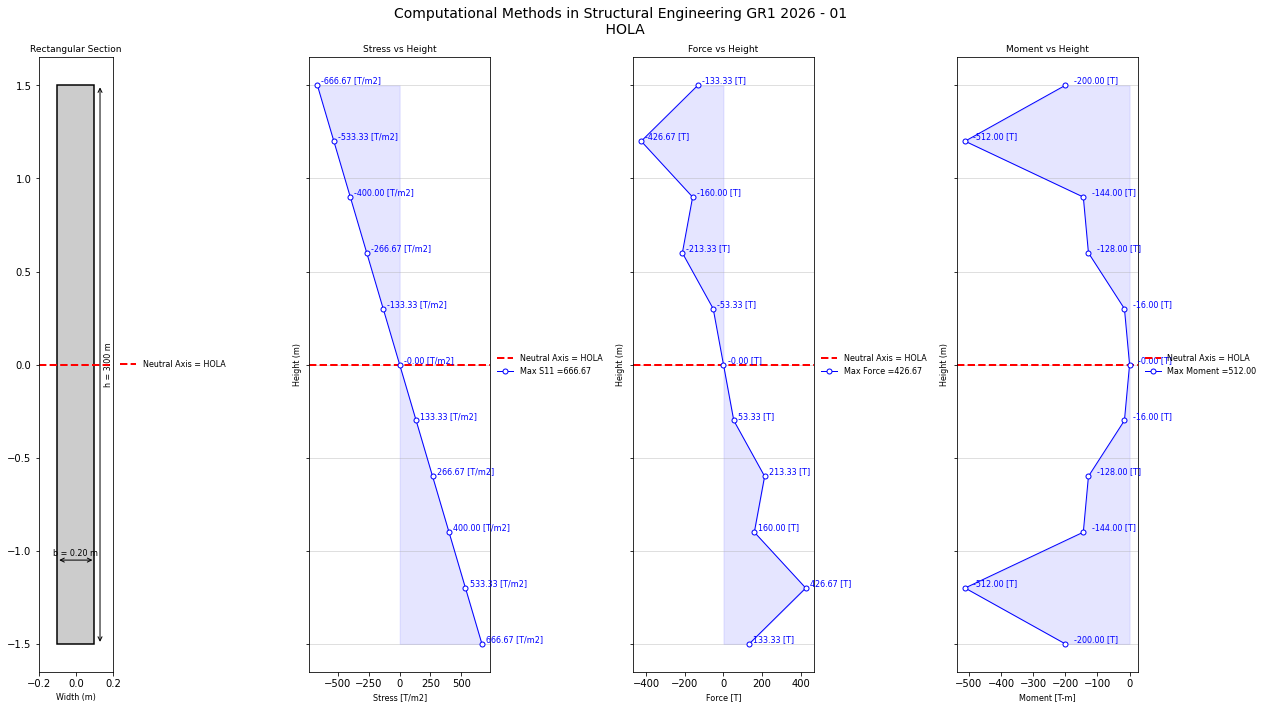

In [12]:
title = 'HOLA'
plot_frame = Plot_Distribution_Stress_Force_Moments(title, eje_n= 0, b = b, h = h,S11_frame= S11_frame,
                                                    hframe= hframe, F_A_frame= F_A_frame, M_frame= M_frame)

plot_frame.plot_stress_force_moment()

#### **Distribución Esfuerzos, Fuerzas y Momentos. [Elemento Shell]**

* Directorio

In [13]:
project_root = Path.cwd().parent
directory = project_root / "files"
print(directory)

c:\Dropbox\Root\Github Repositories\Repo_Computational_Methods\files


##### **Carga de Documentos ".xlsx"**

In [14]:
excel_files = sorted(list(directory.glob("*.xlsx")) + list(directory.glob("*.xls")))
excel_files_df = pd.DataFrame([file.name for file in excel_files], columns=['Excel Files'])
excel_files_df.head(len(excel_files_df))

,Excel Files
0,1. esfuerzos_modelo6_2026_01.xlsx
1,2. nodos_eje_central_m6_2026_01.xlsx


* Selección de Archivos a usar

In [15]:
Stress_joints = ReadExcelFies_compute_avarage_stress(excel_files)
stress_files_df1, joint_name_df = Stress_joints.FileSelect()
stress_files_df1.head(len(stress_files_df1))

,Story,Shell Object,Unique Name,Design Type,Shell Element,Joint,Output Case,Case Type,S11 Top,S22 Top,...,SVM Top,S11 Bottom,S22 Bottom,S12 Bottom,SMax Bottom,SMin Bottom,SVM Bottom,S13 Average,S23 Average,SMaxV Average
0,Story1,W355,355,Wall,355,249,Other,LinStatic,610.61,14.03,...,603.79,610.61,14.03,-5.61,610.66,13.97,603.79,0,0,0
1,Story1,W355,355,Wall,355,203,Other,LinStatic,609.8,9.99,...,604.87,609.8,9.99,-1.01,609.8,9.99,604.87,0,0,0
2,Story1,W355,355,Wall,355,417,Other,LinStatic,459.96,-19.97,...,470.4,459.96,-19.97,-6.51,460.05,-20.06,470.4,0,0,0
3,Story1,W355,355,Wall,355,416,Other,LinStatic,460.76,-15.94,...,469.33,460.76,-15.94,-11.12,461.02,-16.2,469.33,0,0,0
4,Story1,W356,356,Wall,356,416,Other,LinStatic,463.93,-0.1,...,465.46,463.93,-0.1,-21.38,464.92,-1.08,465.46,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,Story1,W389,389,Wall,389,425,Other,LinStatic,-504.66,-733.63,...,709.28,-504.66,-733.63,163.72,-419.37,-818.92,709.28,0,0,0
76,Story1,W390,390,Wall,390,425,Other,LinStatic,-612.02,-1270.43,...,1136.42,-612.02,-1270.43,163.72,-573.56,-1308.9,1136.42,0,0,0
77,Story1,W390,390,Wall,390,434,Other,LinStatic,-309.01,244.63,...,614.72,-309.01,244.63,221.33,322.23,-386.62,614.72,0,0,0
78,Story1,W390,390,Wall,390,260,Other,LinStatic,-910.37,124.36,...,1206.02,-910.37,124.36,407.04,265.28,-1051.3,1206.02,0,0,0


In [16]:
joint_name_df.head(len(joint_name_df))

,nodos
0,208
1,425
2,207
3,423
4,206
5,421
6,205
7,419
8,204
9,417


##### **Esfuerzos Promedio [Shell]**

In [17]:
stress_files_df1["Joint"] = pd.to_numeric(stress_files_df1["Joint"], errors="coerce")
joint_name_df["nodos"] = pd.to_numeric(joint_name_df["nodos"], errors="coerce")

S11_shell = []
Sum_prom_S11_Top = []

for joint_val in joint_name_df["nodos"]:
    filtered_df = stress_files_df1[stress_files_df1["Joint"] == joint_val]

    sum_S11_Top = filtered_df["S11 Top"].sum()
    count = len(filtered_df)
    prom_S11_Top = sum_S11_Top / count
    
    Sum_prom_S11_Top.append(prom_S11_Top)

    S11_shell.append({
        "Joint": joint_val,
        "Count": count,
        "Sum_S11_Top": sum_S11_Top,
        "Avarege_S11_Top": prom_S11_Top
    })

Sum_prom_S11_Top = np.flip(Sum_prom_S11_Top)

S11_shell_df = pd.DataFrame(S11_shell)
S11_shell_df = S11_shell_df.iloc[::-1]
S11_shell_df.head(len(S11_shell_df))

,Joint,Count,Sum_S11_Top,Avarege_S11_Top
10,203,2,1219.60,609.800
9,417,4,1845.26,461.315
8,204,4,1349.84,337.460
7,419,4,908.98,227.245
6,205,4,504.94,126.235
5,421,4,114.42,28.605
4,206,4,-278.64,-69.660
3,423,4,-723.68,-180.920
2,207,4,-1300.76,-325.190
1,425,4,-2233.36,-558.340


##### **Distancia al eje Neutro [Shell]**

In [18]:
tamDiv = h / numdiv                                                   # size of each division along height
ejeNshell = h/2 + tamDiv * poreje                                     # neutral axis position for shell
distENshell = []                                                      # list to store distances from neutral axis

for contNodo in np.arange(0, numdiv + 1, 1):                          # loop from 1 to numdiv + 1 to get distances
    distENshell.append(contNodo * tamDiv - ejeNshell)                 # calculate and append distance from neutral axis
    
distENshell = np.array(distENshell)                                   # convert distances list to numpy array
distENshell = np.flip(distENshell)                                    # flip distances to match shell orientation
distENshell_df = pd.DataFrame(distENshell, columns = ['Distance from Neutral Axis Shell [m]'])   # create DataFrame for distances
distENshell_df.head(len(distENshell_df))                              # display all rows of the distances    

,Distance from Neutral Axis Shell [m]
0,1.41
1,1.11
2,0.81
3,0.51
4,0.21
5,-0.09
6,-0.39
7,-0.69
8,-0.99
9,-1.29


##### **Calculo de Fuerzas [Tracción - Compresión] para Shell**

In [19]:
F_A_Shell = Sum_prom_S11_Top * b * w_frames.flatten()                       # compute axial force contributions at each height                                        
F_A_Shell = np.flip(F_A_Shell)                                              # flip forces to match shell orientation
F_A_Shell_df = pd.DataFrame(F_A_Shell, columns=['Force Shell [T]'])         # create DataFrame for axial forces 
F_A_Shell_df.head(len(F_A_Shell_df))

,Force Shell [T]
0,-242.676
1,-446.672
2,-130.076
3,-144.736
4,-27.864
5,22.884
6,50.494
7,181.796
8,134.984
9,369.052


##### **Distribución de Flexión (Shell) en la sección Transversal**

In [20]:
M_Shell = F_A_Shell * distENshell                                                                   # compute moment contributions at each height
M_Shell_df = pd.DataFrame(M_Shell, columns=['Moment Shell [T-m]'])                                  # create DataFrame for moment contributions
M_Shell_df.head(len(M_frame_df))                                                                    # display all rows of the moment Shell

Summary_Shell = pd.concat([distENshell_df, S11_shell_df, F_A_Shell_df, M_Shell_df], axis=1)         # concatenate stress summary and distances into one DataFrame
Summary_Shell.head(len(Summary_Shell))                                                              # display all rows of the summary DataFrame

,Distance from Neutral Axis Shell [m],Joint,Count,Sum_S11_Top,Avarege_S11_Top,Force Shell [T],Moment Shell [T-m]
0,1.41,208,2,-2426.76,-1213.380,-242.676,-342.17316
1,1.11,425,4,-2233.36,-558.340,-446.672,-495.80592
2,0.81,207,4,-1300.76,-325.190,-130.076,-105.36156
3,0.51,423,4,-723.68,-180.920,-144.736,-73.81536
4,0.21,206,4,-278.64,-69.660,-27.864,-5.85144
5,-0.09,421,4,114.42,28.605,22.884,-2.05956
6,-0.39,205,4,504.94,126.235,50.494,-19.69266
7,-0.69,419,4,908.98,227.245,181.796,-125.43924
8,-0.99,204,4,1349.84,337.460,134.984,-133.63416
9,-1.29,417,4,1845.26,461.315,369.052,-476.07708


###### **Plots**

##### **Summary Plots**

NameError: name 's11_1d' is not defined

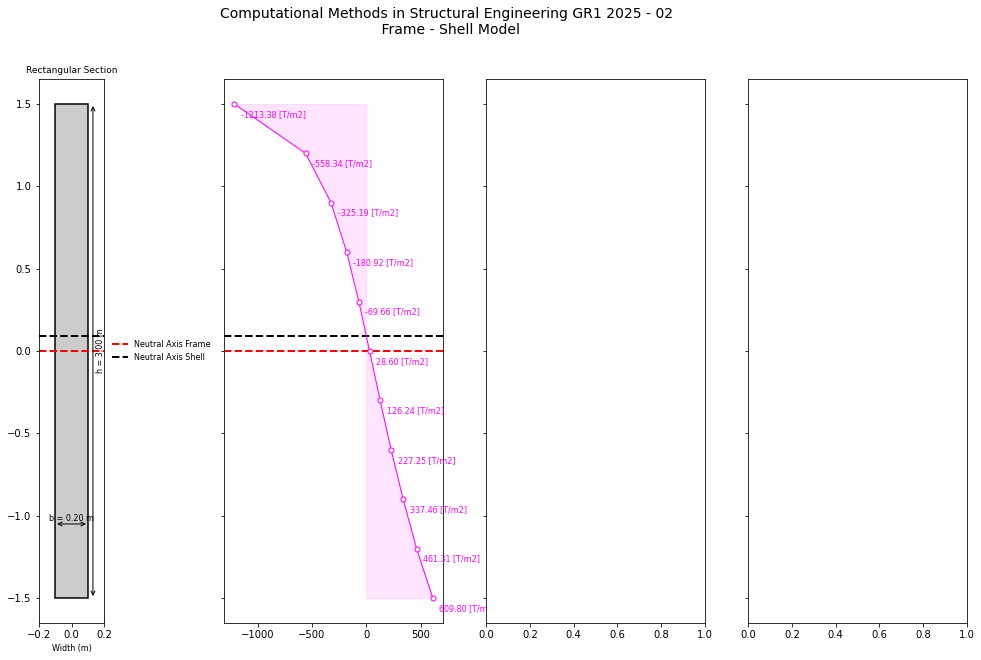

In [21]:
fig, ax = plt.subplots(1, 4, figsize=(18, 10), sharey=True)                                         # create 1x4 subplots and share y-axis across them
fig.suptitle("Computational Methods in Structural Engineering GR1 2025 - 02 \n Frame - Shell Model", fontsize=14, y=0.98)  # set overall figure title

eje_n_frame = 0                                                                                     # neutral axis position for the frame (y = 0)

###################### Section Plot ######################
left = -b / 2                                                                                       # left x-coordinate of the rectangle section
bottom = -h / 2                                                                                     # bottom y-coordinate of the rectangle section
rect = Rectangle((left, bottom), b, h,                                                              # create a Rectangle patch for the cross section
                 linewidth=1.5, edgecolor=(0, 0, 0),
                 facecolor=(0.8, 0.8, 0.8), alpha=1.0)

ax[0].axhline(eje_n_frame, color=(1, 0, 0), linestyle='--', linewidth=2.0,                          # plot neutral axis as dashed red line
              label="Neutral Axis Frame")
ax[0].axhline(-h/2 + ejeNshell, color=(0, 0, 0), linestyle='--', linewidth=2.0,                     # plot neutral axis as dashed black line
              label="Neutral Axis Shell")
ax[0].add_patch(rect)                                                                               # add the rectangular section patch to the axes
ax[0].annotate('', xy=(-b/2, -h/2 + 0.15*h), xytext=(b/2, -h/2 + 0.15*h),                           # draw double-headed arrow for width b
               arrowprops=dict(arrowstyle='<->', linewidth=1))
ax[0].text(0 , -h/2 + 0.17*h, f"b = {b:.2f} m", ha='center', va='top', fontsize=8)                  # label the width b
ax[0].annotate('', xy=(b/2 + 0.15*b, -h/2), xytext=(b/2 + 0.15*b, h/2),                             # draw double-headed arrow for height h
               arrowprops=dict(arrowstyle='<->', linewidth=1))
ax[0].text(b/2 + 0.25*b, 0, f"h = {h:.2f} m", rotation=90, va='center', ha='left', fontsize=8)      # label the height h

ax[0].set_xlim(-b, b)                                                                               # set x-limits for section plot
ax[0].set_aspect('equal')                                                                           # keep equal aspect ratio
ax[0].set_xlabel("Width (m)", fontsize=8)                                                           # x-axis label
ax[0].set_title("Rectangular Section", fontsize=9, color=(0, 0, 0))                                 # title for the section subplot
ax[0].legend(fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)                 # legend for subplot 0


###################### Stress vs Height Plot ######################
s11_1dS = np.flip(Sum_prom_S11_Top)                                                                           # flatten bending stress array to 1D
hshell_1d = distENshell                                                                             # flatten height array to 1D

ax[1].axhline(eje_n_frame, color=(1, 0, 0), linestyle='--', linewidth=2.0,                          # plot neutral axis on stress plot
             label=f'Neutral Axis Frame')
ax[1].axhline(-h/2 + ejeNshell, color=(0, 0, 0), linestyle='--', linewidth=2.0,                     # plot neutral axis as dashed black line
              label="Neutral Axis Shell")



ax[1].plot(s11_1dS, hshell_1d - (h/2 - ejeNshell), color=(1, 0, 1), marker='o', markersize=5, markerfacecolor='w', markeredgewidth=1, linestyle='-', linewidth=1.0,  # plot stress vs height
             label=f'Max S11_Shell ={np.max(np.abs(s11_1dS)):.2f}')
ax[1].fill_betweenx(hshell_1d - (h/2 - ejeNshell), 0, s11_1dS, color=(1, 0, 1), alpha=0.1)                                  # fill area under stress curve horizontally

for x, y in zip(s11_1dS, hshell_1d):                                                                 # annotate each stress point with its value
    ax[1].text(x + np.max(np.abs(s11_1dS))*0.05, y,f'{x:.2f} [T/m2]', fontsize=8, color= (1, 0, 1), ha='left', va='bottom')



ax[1].plot(s11_1d, hframe_1d, color=(0, 0, 1), marker='o', markersize=5, markerfacecolor='w', markeredgewidth=1, linestyle='-', linewidth=1.0,  # plot stress vs height
             label=f'Max S11_frame ={np.max(np.abs(s11_1d)):.2f}')
ax[1].fill_betweenx(hframe, 0, s11_1d, color=(0, 0, 1), alpha=0.1)                                  # fill area under stress curve horizontally

for x, y in zip(s11_1d, hframe_1d):                                                                 # annotate each stress point with its value
    ax[1].text(x + np.max(np.abs(s11_1d))*0.05, y,f'{x:.2f} [T/m2]', fontsize=8, color= (0, 0, 1), ha='left', va='bottom')






ax[1].set_xlabel("Stress [T/m2]", fontsize=8)                                                       # x-axis label for stress plot
ax[1].set_ylabel("Height (m)", fontsize=8)                                                          # y-axis label for stress plot
ax[1].set_title(f'Stress vs Height Shell', fontsize= 9, color=(0, 0, 0))                                  # title for stress subplot
ax[1].legend(fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)                 # legend for subplot 1
ax[1].grid(which='both', axis='y', alpha=0.5)                                                       # enable horizontal grid lines


###################### Force vs Height Plot ######################
F_A_shell_1d = F_A_Shell                                                                  # flatten axial force contributions to 1D

ax[2].axhline(eje_n_frame, color=(1, 0, 0), linestyle='--', linewidth=2.0,                          # plot neutral axis on force plot
             label=f'Neutral Axis Frame')
ax[2].axhline(-h/2 + ejeNshell, color=(0, 0, 0), linestyle='--', linewidth=2.0,                     # plot neutral axis as dashed black line
              label="Neutral Axis Shell")


ax[2].plot(F_A_shell_1d, hshell_1d - (h/2 - ejeNshell), color=(1, 0, 1), marker='o', markersize=5, markerfacecolor='w', markeredgewidth=1, linestyle='-', linewidth=1.0,  # plot force vs height
             label=f'Max F_A_Shell ={np.max(np.abs(F_A_shell_1d)):.2f}')
ax[2].fill_betweenx(hshell_1d - (h/2 - ejeNshell), 0, F_A_shell_1d, color=(1, 0, 1), alpha=0.1)                            # fill area under force curve horizontally

for x, y in zip(F_A_shell_1d, hshell_1d):                                                           # annotate each force point with its value
    ax[2].text(x + np.max(np.abs(F_A_shell_1d))*0.05, y,f'{x:.2f} [T]', fontsize=8, color= (1, 0, 1), ha='left', va='bottom')




ax[2].plot(F_A_frame_1d, hframe_1d, color=(0, 0, 1), marker='o', markersize=5, markerfacecolor='w', markeredgewidth=1, linestyle='-', linewidth=1.0,  # plot force vs height
             label=f'Max F_A_frame ={np.max(np.abs(F_A_frame_1d)):.2f}')
ax[2].fill_betweenx(hframe, 0, F_A_frame_1d, color=(0, 0, 1), alpha=0.1)                            # fill area under force curve horizontally

for x, y in zip(F_A_frame_1d, hframe_1d):                                                           # annotate each force point with its value
    ax[2].text(x + np.max(np.abs(F_A_frame_1d))*0.05, y,f'{x:.2f} [T]', fontsize=8, color= (0, 0, 1), ha='left', va='bottom')





ax[2].set_xlabel("Force [T]", fontsize=8)                                                           # x-axis label for force plot
ax[2].set_ylabel("Height (m)", fontsize=8)                                                          # y-axis label for force plot
ax[2].set_title(f'Force vs Height', fontsize= 9, color=(0, 0, 0))                                   # title for force subplot
ax[2].legend(fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)                 # legend for subplot 2
ax[2].grid(which='both', axis='y', alpha=0.5)                                                       # enable horizontal grid lines


###################### Moment vs Height Plot ######################
Mtotal_frame = np.sum(M_frame) * (h / numdiv) / h
Mtotal_shell = np.sum(M_Shell) * (h / numdiv) / h

M_shell_1d = M_Shell                                                                                # moment contributions are already 1D

ax[3].axhline(eje_n_frame, color=(1, 0, 0), linestyle='--', linewidth=2.0,                          # plot neutral axis on moment plot
             label=f'Neutral Axis Frame')
ax[3].axhline(-h/2 + ejeNshell, color=(0, 0, 0), linestyle='--', linewidth=2.0,                     # plot neutral axis as dashed black line
              label="Neutral Axis Shell")




ax[3].plot(M_shell_1d, hshell_1d - (h/2 - ejeNshell), color=(1, 0, 1), marker='o', markersize=5, markerfacecolor='w', markeredgewidth=1, linestyle='-', linewidth=1.0,  # plot moment vs height
             label=f'Total M_shell ={np.max(np.abs(Mtotal_shell)):.2f}')
ax[3].fill_betweenx(hshell_1d - (h/2 - ejeNshell), 0, M_shell_1d, color=(1, 0, 1), alpha=0.1)                           # fill area under moment curve horizontally

for x, y in zip(M_shell_1d, hshell_1d):                                                             # annotate each moment point with its value
    ax[3].text(x + np.max(np.abs(M_shell_1d))*0.05, y,f'{x:.2f} [T]', fontsize=8, color= (1, 0, 1), ha='left', va='bottom')




ax[3].plot(M_frame_1d, hframe_1d, color=(0, 0, 1), marker='o', markersize=5, markerfacecolor='w', markeredgewidth=1, linestyle='-', linewidth=1.0,  # plot moment vs height
             label=f'Total M_frame ={np.max(np.abs(Mtotal_frame)):.2f}')
ax[3].fill_betweenx(hframe, 0, M_frame_1d, color=(0, 0, 1), alpha=0.1)                              # fill area under moment curve horizontally

for x, y in zip(M_frame_1d, hframe_1d):                                                             # annotate each moment point with its value
    ax[3].text(x + np.max(np.abs(M_frame_1d))*0.05, y,f'{x:.2f} [T]', fontsize=8, color= (0, 0, 1), ha='left', va='bottom')


ax[3].set_xlabel("Moment [T-m]", fontsize=8)                                                        # x-axis label for moment plot
ax[3].set_ylabel("Height (m)", fontsize=8)                                                          # y-axis label for moment plot
ax[3].set_title(f'Moment vs Height', fontsize= 9, color=(0, 0, 0))                                  # title for moment subplot
ax[3].legend(fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)                 # legend for subplot 3
ax[3].grid(which='both', axis='y', alpha=0.5)                                                       # enable horizontal grid lines

plt.tight_layout()                                                                                  # adjust subplots to fit into figure area
plt.show()                                                                                          # display the figure                                                          
